In [1]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb
import src.concept_utils as cu


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-09-24 14:48:22.507941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 14:48:22.545162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-09-24 14:48:23.256000: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
sys.path.append(os.getcwd())
sys.path

['/home/thomas/.conda/envs/debiafting/lib/python313.zip',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/lib-dynload',
 '',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages',
 '/tmp/tmpthuxp2_x',
 '/home/thomas/Documents/ENS/IAS/S2/XCL/CVDB']

<Axes: >

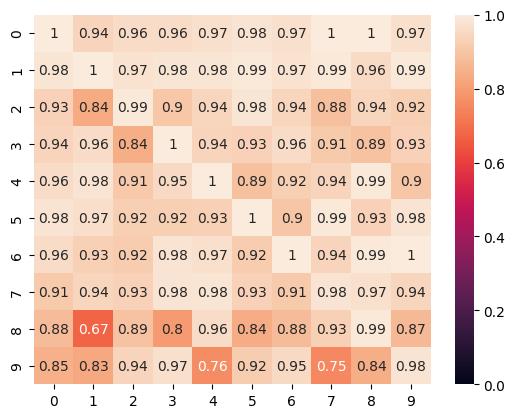

In [4]:
exp_id = 0
exp_name = "MNIST"
with open("models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    model_res = pkl.load(f)
sb.heatmap(model_res["correctness_matrix"]/model_res["appearance_matrix"], vmin=0, vmax=1, annot=True)


In [37]:
with open(f"models/{exp_name}/concepts_{0}_{1}.pkl", "rb") as f:
    concept_res = pkl.load(f)

In [38]:
amount_of_concept = 30
studied_bias = 8
step_amount = 70

<Axes: >

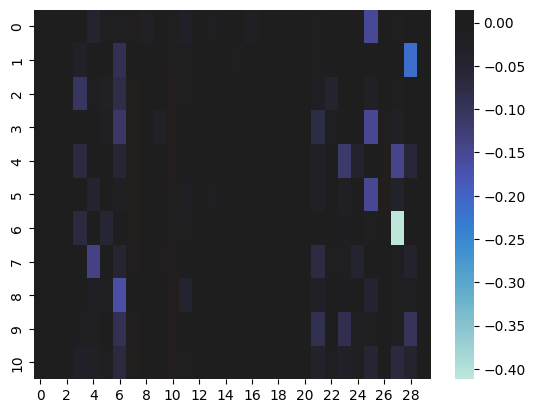

In [40]:
with open(f"models/{exp_name}/bias_{exp_id}_{1}.pkl", "rb") as f:
    bias_res = pkl.load(f)

table = []
for i in range(10):
    table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
table.append(sum(table)/len(table))
sb.heatmap(table, center=0, annot=False)

<Axes: >

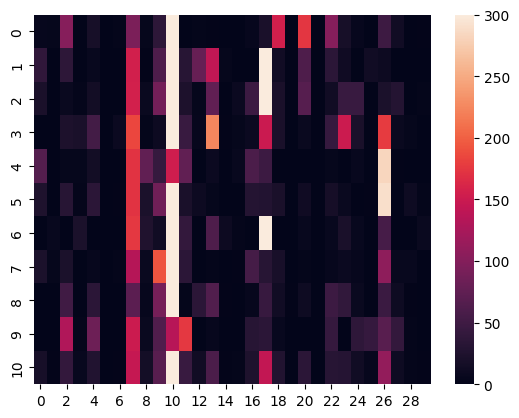

In [41]:
table1 = []
for i in range(10):
    table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
table1.append(sum(table1)/len(table1))
sb.heatmap(table1, vmin=0, vmax=300, annot=False)   

<Axes: >

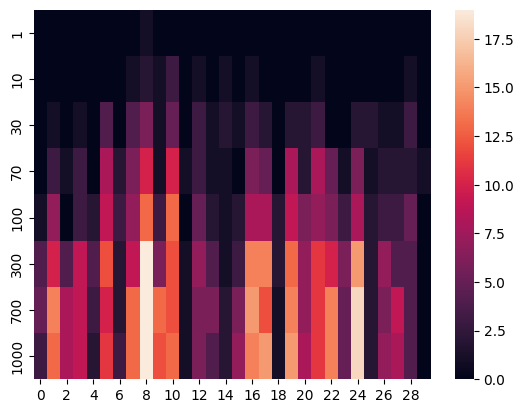

In [43]:
truc = []
for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
    table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
    truc.append(table_[0])
# table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])

<Axes: >

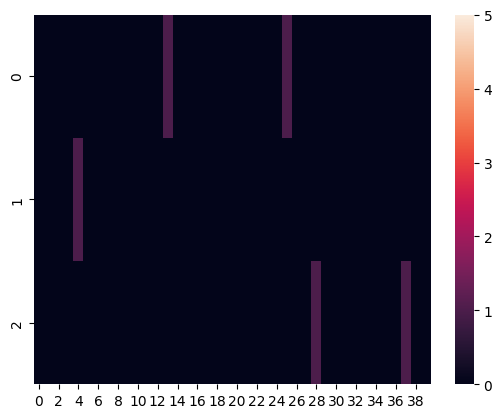

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

<Axes: >

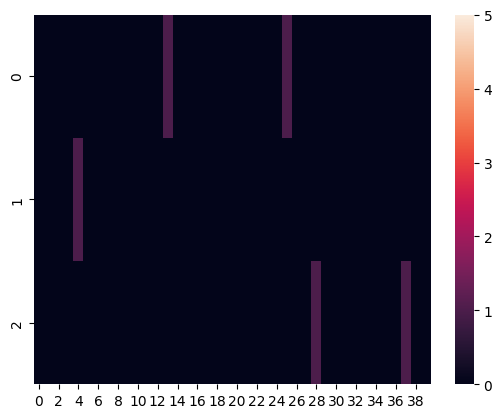

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

In [30]:
table_

(array([0., 0., 2., 0., 2., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,

In [17]:
data_path = os.getcwd() + "/data/MNIST"
device = "cuda"
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=res["batch_size"], data_label_correlation=res["test_correlation"], train=False)
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

assert(os.path.exists(f"models/{exp_name}/model_{exp_id}"))
model.load_state_dict(torch.load(f"models/{exp_name}/model_{exp_id}", weights_only=True))

base_acc = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 78.1%, Avg loss: 0.659705 



In [19]:
import seaborn as sb

<Axes: >

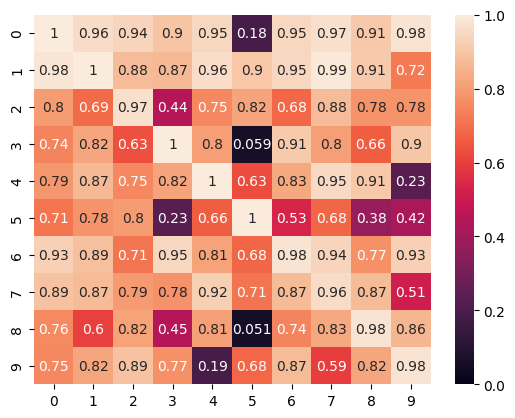

In [21]:
sb.heatmap(base_acc, vmin=0, vmax=1, annot=True)

<Axes: >

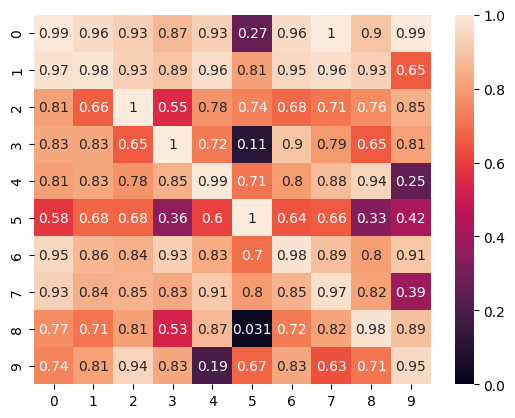

In [20]:
sb.heatmap(res["accuracy_matrix"], vmin=0, vmax=1, annot=True)